In [1]:
# IMPORT LIBRARY
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [2]:
# LOAD DATA
df = pd.read_parquet("data/clean_yellow_taxi_2024_q1.parquet")
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,average_speed_mph,tip_percentage,high_tip
0,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,...,3.75,0.0,1.0,18.75,2.5,0.0,6.600000,16.363636,0.375000,1
1,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,...,3.00,0.0,1.0,31.30,2.5,0.0,17.916667,15.739535,0.128755,0
2,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,...,2.00,0.0,1.0,17.00,2.5,0.0,8.300000,10.120482,0.200000,1
3,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.8,1.0,N,211,148,1,...,3.20,0.0,1.0,16.10,2.5,0.0,6.100000,7.868852,0.405063,1
4,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.7,1.0,N,148,141,1,...,6.90,0.0,1.0,41.50,2.5,0.0,32.383333,8.708183,0.233108,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6373879 entries, 0 to 6373878
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

# EDA

## 1. What percentage of credit-card trips are high-tip rides?

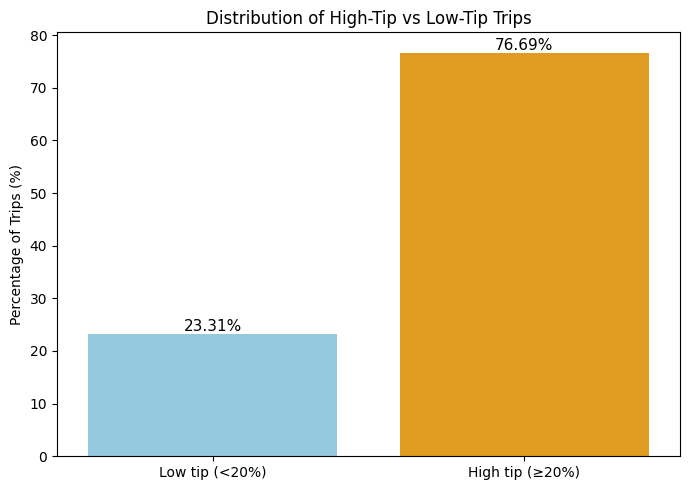

In [22]:
high_tip_dist = (
    df["high_tip"]
    .value_counts(normalize=True)
    .sort_index()
    .reset_index()
)

high_tip_dist.columns = ["high_tip", "percentage"]
high_tip_dist["percentage"] *= 100

# Rename labels
high_tip_dist["high_tip"] = high_tip_dist["high_tip"].map({
    0: "Low tip (<20%)",
    1: "High tip (≥20%)"
})

# Colors
bar_colors = ["skyblue", "orange"]

# Plot
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=high_tip_dist,
    x="high_tip",
    y="percentage",
    hue="high_tip",
    palette=bar_colors,
    legend=False
)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribution of High-Tip vs Low-Tip Trips")
plt.xlabel("")
plt.ylabel("Percentage of Trips (%)")
plt.tight_layout()
plt.show()

The target distribution shows that 76.69% of credit-card trips are classified as high-tip rides, while 23.31% are low-tip rides. This means the target variable is moderately imbalanced, with high-tip trips forming the majority class. Because of this imbalance, model evaluation should not rely only on accuracy: a model could achieve relatively high accuracy by mostly predicting the majority class. Therefore, precision, recall, F1-score, ROC-AUC, and PR-AUC should also be used to evaluate how well the model distinguishes between high-tip and low-tip rides.

## 2. How does tip percentage vary by pickup hour and day in week? Between weekday and weekend?

In [5]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek

day_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df["pickup_day_name"] = df["pickup_day_of_week"].map(day_map)
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,average_speed_mph,tip_percentage,high_tip,pickup_hour,pickup_day_of_week,pickup_day_name
0,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.8,1.0,N,140,236,1,...,18.75,2.5,0.0,6.600000,16.363636,0.375000,1,0,0,Monday
1,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.7,1.0,N,236,79,1,...,31.30,2.5,0.0,17.916667,15.739535,0.128755,0,0,0,Monday
2,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.4,1.0,N,79,211,1,...,17.00,2.5,0.0,8.300000,10.120482,0.200000,1,0,0,Monday
3,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.8,1.0,N,211,148,1,...,16.10,2.5,0.0,6.100000,7.868852,0.405063,1,0,0,Monday
4,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.7,1.0,N,148,141,1,...,41.50,2.5,0.0,32.383333,8.708183,0.233108,1,0,0,Monday


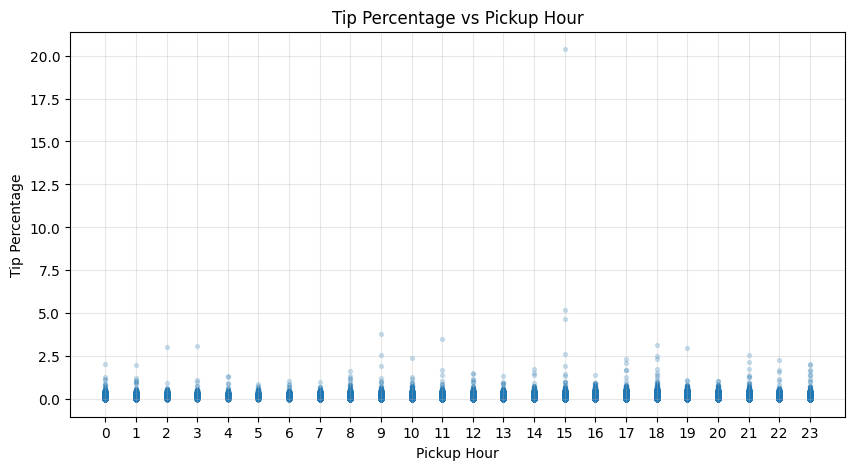

In [6]:
# Sample for readability
scatter_sample = df.sample(
    n=min(100_000, len(df)),
    random_state=42
)


plt.figure(figsize=(10, 5))

plt.scatter(
    scatter_sample["pickup_hour"],
    scatter_sample["tip_percentage"],
    alpha=0.2,
    s=8
)

plt.title("Tip Percentage vs Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Tip Percentage")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.show()

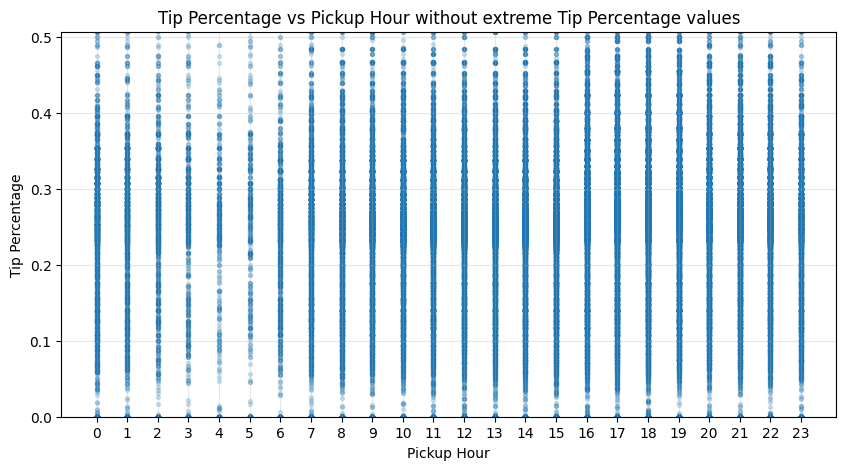

In [7]:
plt.figure(figsize=(10, 5))

plt.scatter(
    scatter_sample["pickup_hour"],
    scatter_sample["tip_percentage"],
    alpha=0.2,
    s=8
)

plt.title("Tip Percentage vs Pickup Hour without extreme Tip Percentage values")
plt.xlabel("Pickup Hour")
plt.ylabel("Tip Percentage")
plt.xticks(range(0, 24))
plt.ylim(0, df["tip_percentage"].quantile(0.99))
plt.grid(True, alpha=0.3)

plt.show()

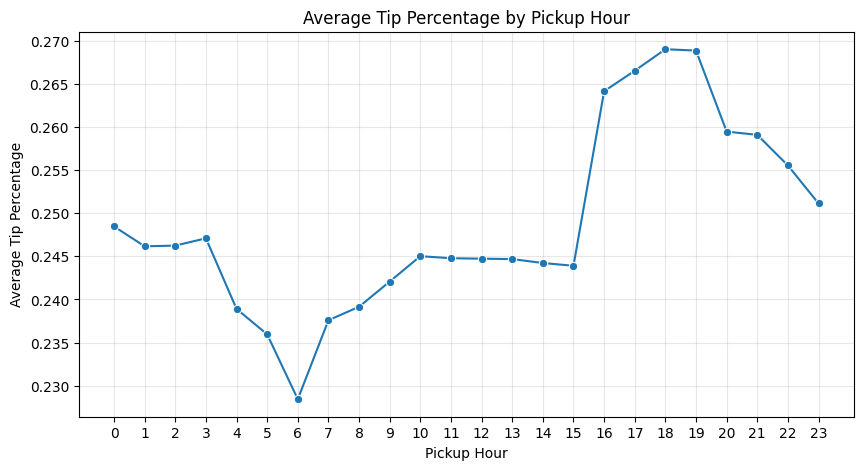

In [8]:
hourly_tip = (
    df
    .groupby("pickup_hour")
    .agg(
        avg_tip_percentage=("tip_percentage", "mean"),
        median_tip_percentage=("tip_percentage", "median"),
        trip_count=("tip_percentage", "count")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_tip,
    x="pickup_hour",
    y="avg_tip_percentage",
    marker="o"
)

plt.title("Average Tip Percentage by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Tip Percentage")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.show()

With the combination of the 3 graphs above, we can conlude that afternoon and evening are associated with the higher average percentage of tip.
Furthermore, from the second graph, the density of samples in the range from `4am` to `6am` value have fewer data point based on the thinness of points distribution.

The peak average tip percentage are `18` and `19` o'clock. By the same value, the 2nd scatter plot show that they are more thick/high data points density than the range as mentioned above.

There is also a significant increase in tip percentage from `16` o'clock as this is the common leaving university/work time and night ativities.

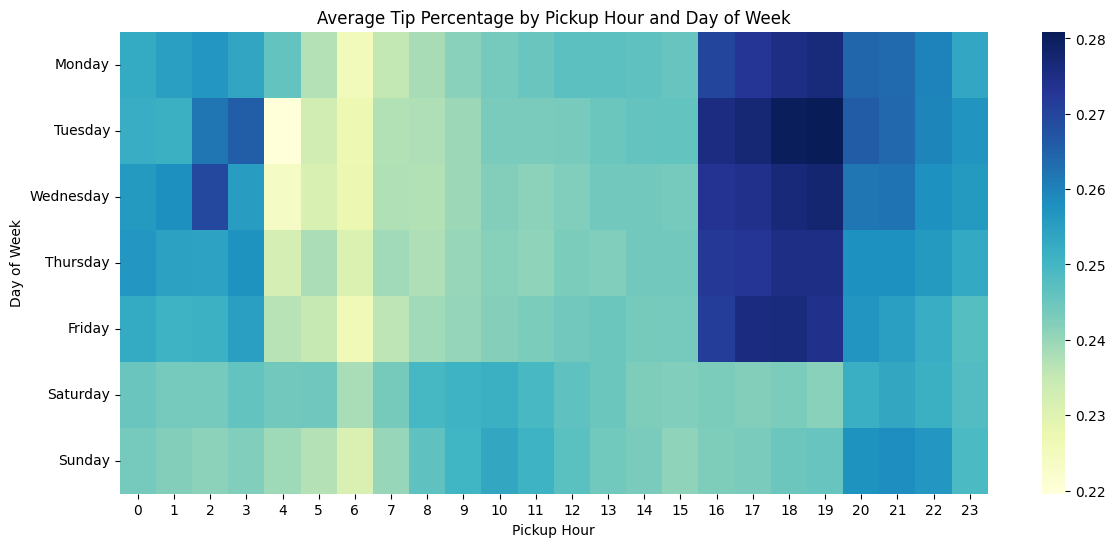

In [9]:
hour_day_tip = (
    df
    .groupby(["pickup_day_name", "pickup_hour"])["tip_percentage"]
    .mean()
    .reset_index()
)

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

heatmap_data = hour_day_tip.pivot(
    index="pickup_day_name",
    columns="pickup_hour",
    values="tip_percentage"
)

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlGnBu"
)

plt.title("Average Tip Percentage by Pickup Hour and Day of Week")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")

plt.show()

As the analyse above, there will be a recognisable highest tip percentage from `16` to `19` o'clock, moreover, from the heatmap, we can now see that phenomenon only happen in workday. The tip percentage in late night (from `20` to `23`) on weekend also has a great number compared to other hour in weekend. And the remarkable low tip percentage on `6` o'clock is commonly happened throughout the week.

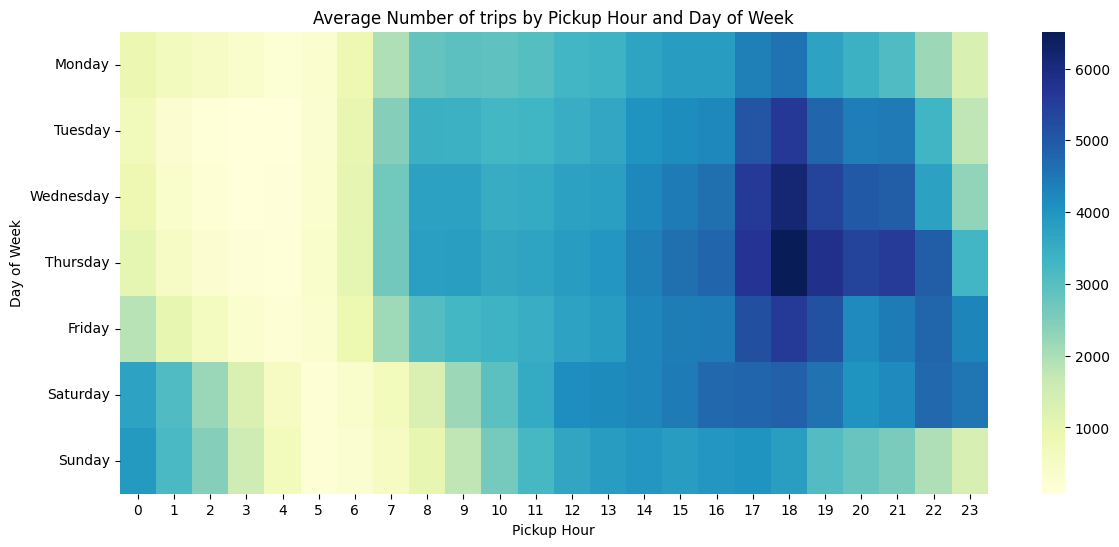

In [10]:
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date

hour_day_daily_count = (
    df
    .groupby(["pickup_date", "pickup_day_name", "pickup_hour"])
    .size()
    .reset_index(name="sample_count")
)

hour_day_avg_count = (
    hour_day_daily_count
    .groupby(["pickup_day_name", "pickup_hour"])["sample_count"]
    .mean()
    .reset_index()
)

heatmap_data = hour_day_avg_count.pivot(
    index="pickup_day_name",
    columns="pickup_hour",
    values="sample_count"
)

heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlGnBu"
)

plt.title("Average Number of trips by Pickup Hour and Day of Week")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")

plt.show()

To have a more precise conslusion, we have the heat map above show average number of trips by hour and weekday. We now can conclude that workdays and time between `7` to `22` o'clock (evening) are associated with the higher chance to have more trips and higher tip, especially evening hour in workdays.

## 3. Which pickup/dropoff locations have higher average tip percentage?

### Pickup

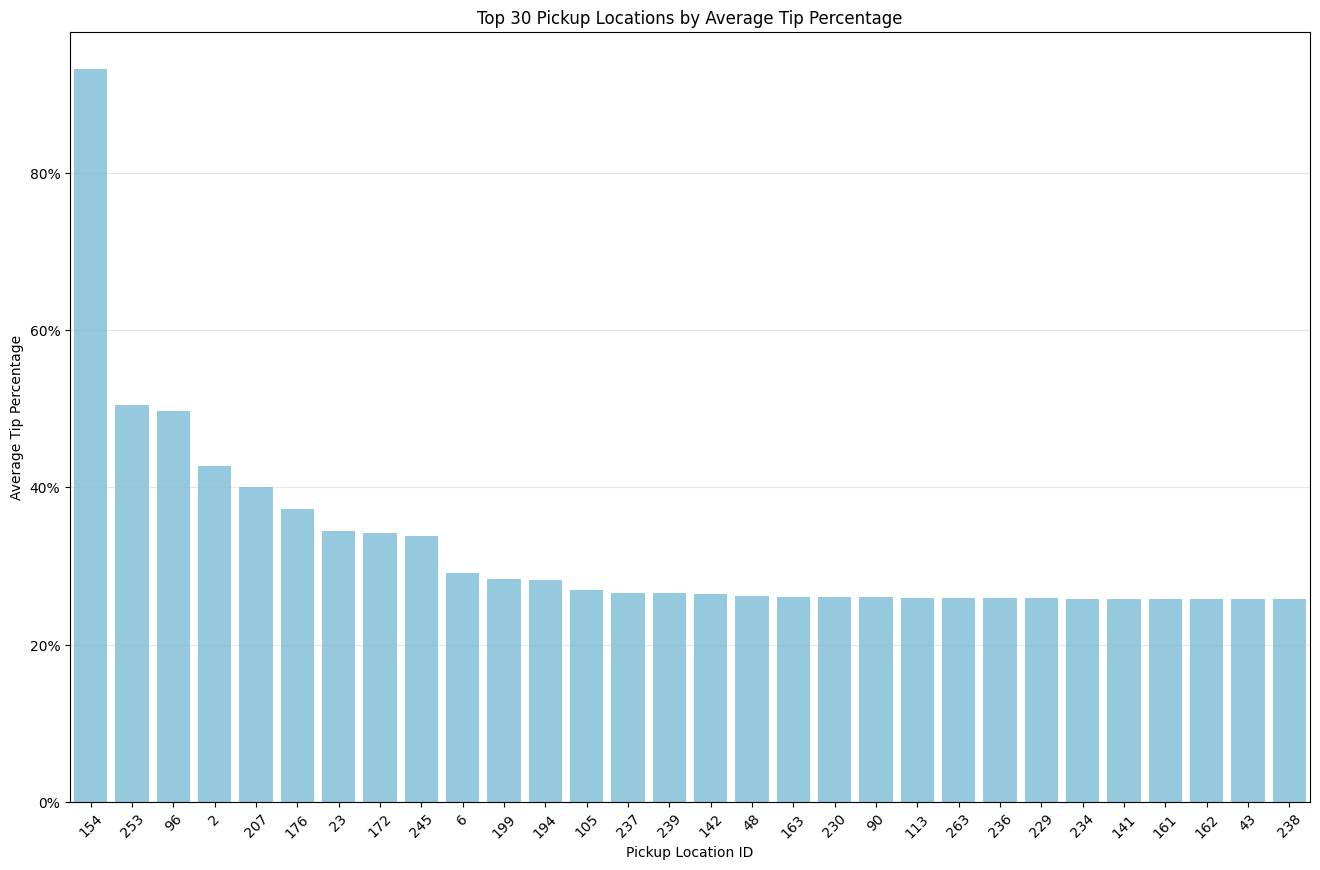

In [11]:
top_pickup_tip = (
    df
    .groupby("PULocationID", as_index=False)
    .agg(avg_tip_percentage=("tip_percentage", "mean"))
    .sort_values("avg_tip_percentage", ascending=False)
    .head(30)
)

# Treat location ID as categorical
top_pickup_tip["PULocationID"] = top_pickup_tip["PULocationID"].astype(str)

# Vertical bar chart
plt.figure(figsize=(16, 10))

sns.barplot(
    data=top_pickup_tip,
    x="PULocationID",
    y="avg_tip_percentage",
    color="skyblue"
)

plt.title("Top 30 Pickup Locations by Average Tip Percentage")
plt.xlabel("Pickup Location ID")
plt.ylabel("Average Tip Percentage")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

From the barchart, we can see the top 10 places have a recognizable different from others. THe first position even outstanding all other places with the average percentage of mostly `100%` while second rank place only has the number of about `50%`. From No. 11th till 30th, there are seem to be no differnces between places and the mojority of these places take about the number of `30%` of tip. 

With the location zone ID lookup, we can have more information about whether the center or urban has the higher chance to recieve a higher percentage of tip. 

### Dropoff

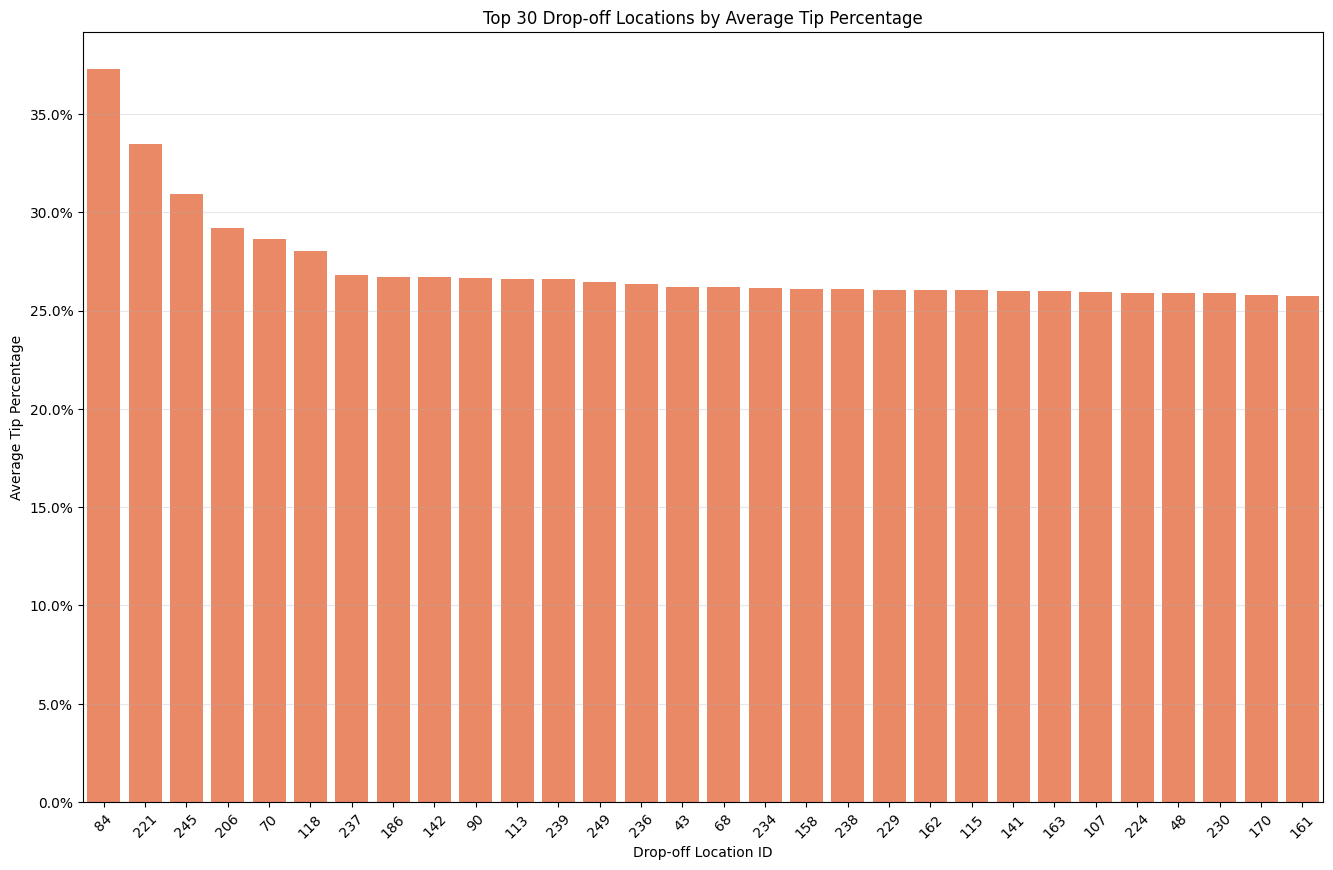

In [12]:
top_pickup_tip = (
    df
    .groupby("DOLocationID", as_index=False)
    .agg(avg_tip_percentage=("tip_percentage", "mean"))
    .sort_values("avg_tip_percentage", ascending=False)
    .head(30)
)

# Treat location ID as categorical
top_pickup_tip["DOLocationID"] = top_pickup_tip["DOLocationID"].astype(str)

# Vertical bar chart
plt.figure(figsize=(16, 10))

sns.barplot(
    data=top_pickup_tip,
    x="DOLocationID",
    y="avg_tip_percentage",
    color="coral"
)

plt.title("Top 30 Drop-off Locations by Average Tip Percentage")
plt.xlabel("Drop-off Location ID")
plt.ylabel("Average Tip Percentage")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

Unlike the remarklably different from places in the pick-up chart, the drop-off chart seems to have more stable observation. The most recognizable increase starts from location ID `118`. From rank No. 1 to No. 6, the gap between each location is quite observable. The 1st position recieve the number of more than `35%` tip, on the other hand, the No.6 only recieve about `27%`. From No.7 till 30, the numbers do not see any noticeable difference. Using a encoded location, we cannot see any practical insght yet, but with a lacation MetaData, we can have a more detailed sight for such information as if the combinations of pick-up locations and drop-off locations truely matter or which combination can possibly lead to higer probability of recieving higher tip or higher percentage of tip.

## 4. Do trips duration, trip distance and trip fare affect the tip percentages?

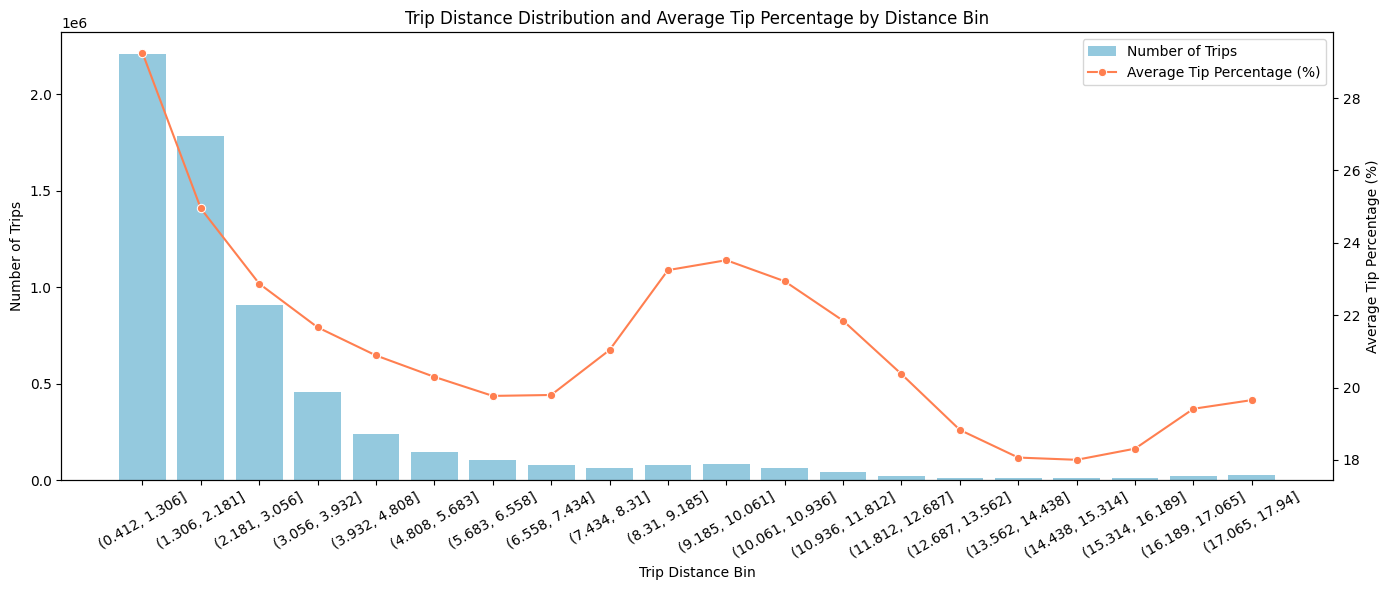

In [13]:
plot_df = df[["trip_distance", "tip_percentage"]].dropna().copy()

plot_df["distance_bin"] = pd.cut(
    plot_df["trip_distance"],
    bins=20
)

distance_tip_summary = (
    plot_df
    .groupby("distance_bin", observed=True)
    .agg(
        trip_count=("trip_distance", "count"),
        avg_tip_percentage=("tip_percentage", "mean")
    )
    .reset_index()
)

distance_tip_summary["avg_tip_percentage"] *= 100

distance_tip_summary["distance_bin_label"] = distance_tip_summary["distance_bin"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=distance_tip_summary,
    x="distance_bin_label",
    y="trip_count",
    ax=ax1,
    color = 'skyblue',
    label="Number of Trips"
)

ax1.set_xlabel("Trip Distance Bin")
ax1.set_ylabel("Number of Trips")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()

sns.lineplot(
    data=distance_tip_summary,
    x="distance_bin_label",
    y="avg_tip_percentage",
    marker="o",
    ax=ax2,
    color = 'coral',
    label="Average Tip Percentage (%)"
)

ax2.set_ylabel("Average Tip Percentage (%)")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    frameon=True
)

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

plt.title("Trip Distance Distribution and Average Tip Percentage by Distance Bin")
plt.tight_layout()
plt.show()

The graph contains two separate parts which are barchart showing the number of trips with differnet distance and the other one is each scope of distance average percentage of tip. From the barplot, we can see a direct sight that most of hte yellow taxi trips are less than `3` miles. in overall, Its distribution seems to have a stable decrease as the bar continuosly decreasing. And also if we look carefully, there are 3 different curve points. It is the shortest distance from `0.412` to `1.306`, the middle - `9.185` to `10.061`, and the longest `17.065` to `17.94`. However, the differences in these curve points from other data point are quite noticeable. Although there is a major differnce between the first curve point compared to the local data point which the first curve point and the data point following are so outstanding, the two other curve points seem to have a really small higher than its neighbors.

We now move to the average tip percentage line, there is a simular pattern in this plot that the line also has three curve points and they are the exact bin like the number of trip bar chart. How ever, these curve points create obvious differences from these points to its neighbors. Overall, we can say that beside the two end points, which are the longest and shortest distance, the medium distance is also associated with the higher percentage of tip.

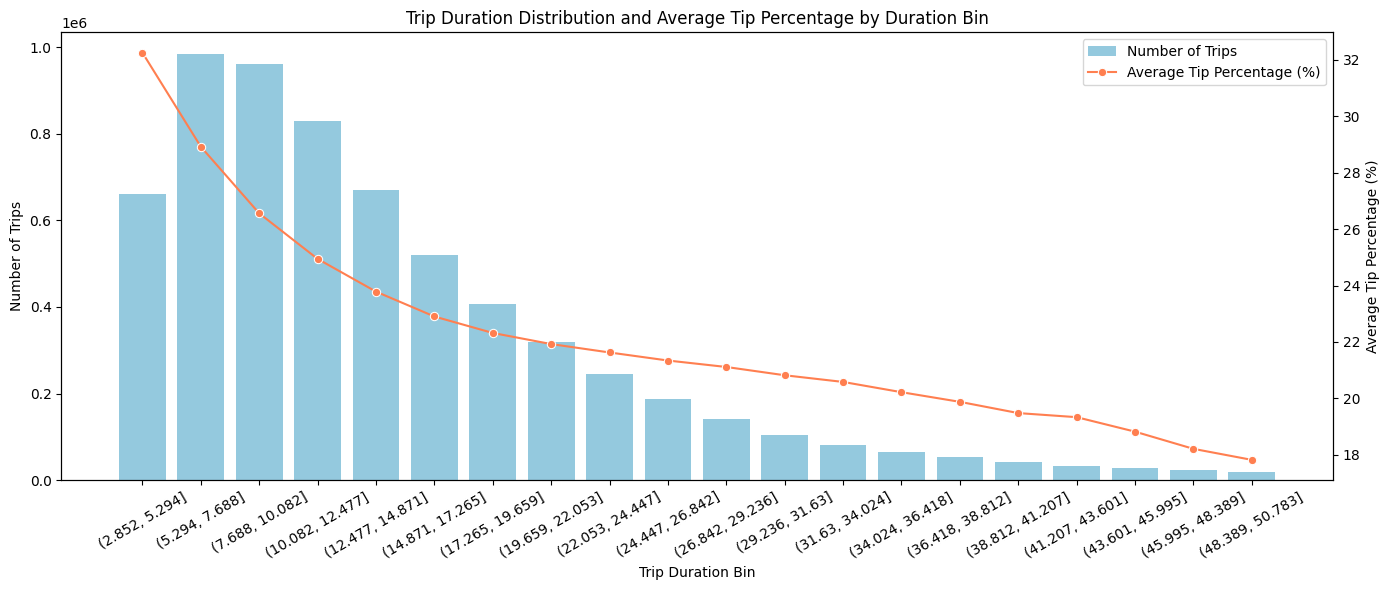

In [14]:
plot_df = df[["trip_duration_minutes", "tip_percentage"]].dropna().copy()

plot_df["duration_bin"] = pd.cut(
    plot_df["trip_duration_minutes"],
    bins=20
)

duration_tip_summary = (
    plot_df
    .groupby("duration_bin", observed=True)
    .agg(
        trip_count=("trip_duration_minutes", "count"),
        avg_tip_percentage=("tip_percentage", "mean")
    )
    .reset_index()
)

duration_tip_summary["avg_tip_percentage"] *= 100

duration_tip_summary["duration_bin_label"] = duration_tip_summary["duration_bin"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=duration_tip_summary,
    x="duration_bin_label",
    y="trip_count",
    ax=ax1,
    color = 'skyblue',
    label="Number of Trips"
)

ax1.set_xlabel("Trip Duration Bin")
ax1.set_ylabel("Number of Trips")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()

sns.lineplot(
    data=duration_tip_summary,
    x="duration_bin_label",
    y="avg_tip_percentage",
    marker="o",
    ax=ax2,
    color = 'coral',
    label="Average Tip Percentage (%)"
)

ax2.set_ylabel("Average Tip Percentage (%)")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    frameon=True
)

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

plt.title("Trip Duration Distribution and Average Tip Percentage by Duration Bin")
plt.tight_layout()
plt.show()

Overall, the chart show an inverse relationship between trip duration and tip percentage. From the bar chart, except the data point with number of minute about less than `5.2` is ranked about 4th to 5th in the number of trips, other data points follow a simular pattern that the longer the trip take, the less number of trip. And we can also obverve that trips with duration less than `20` minutes account for the majority of number of trips. Unlike the bar chart, the line chart fell sharply at first before declining more gradually toward the end of the period. Overall, The longer trips associate with the lower tip percentage.

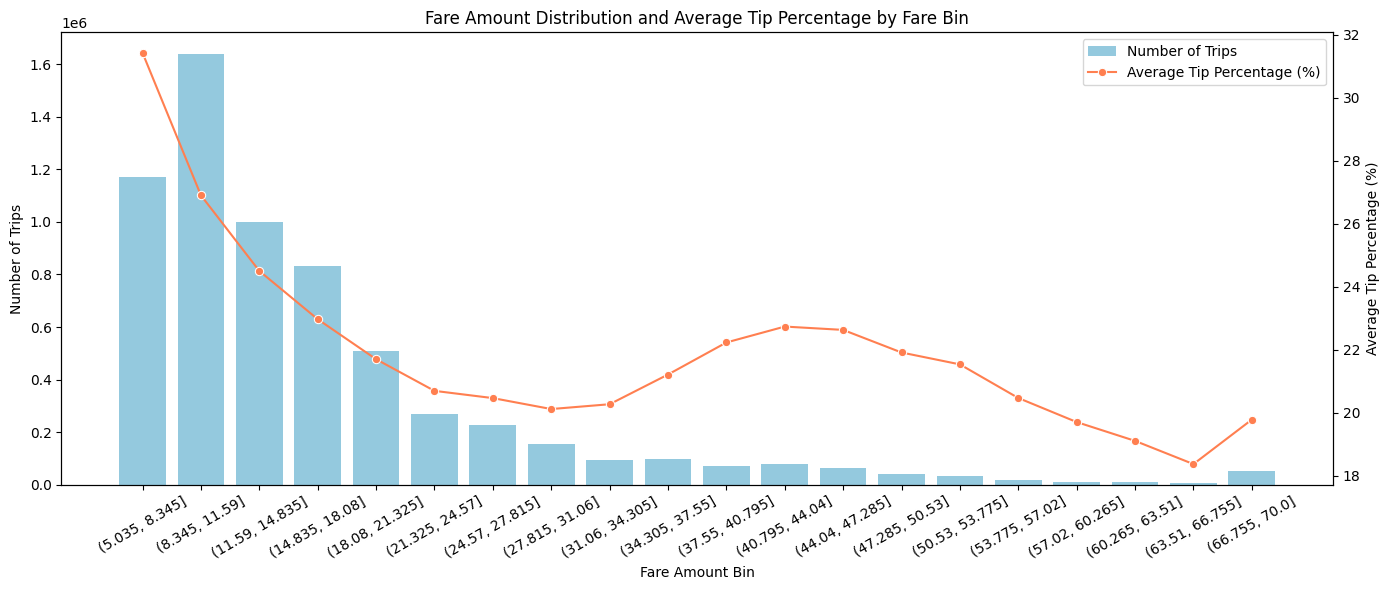

In [15]:
plot_df = df[["fare_amount", "tip_percentage"]].dropna().copy()

plot_df["fare_bin"] = pd.cut(
    plot_df["fare_amount"],
    bins=20
)

fare_tip_summary = (
    plot_df
    .groupby("fare_bin", observed=True)
    .agg(
        trip_count=("fare_amount", "count"),
        avg_tip_percentage=("tip_percentage", "mean")
    )
    .reset_index()
)

fare_tip_summary["avg_tip_percentage"] *= 100

fare_tip_summary["fare_bin_label"] = fare_tip_summary["fare_bin"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=fare_tip_summary,
    x="fare_bin_label",
    y="trip_count",
    ax=ax1,
    color = 'skyblue',
    label="Number of Trips"
)

ax1.set_xlabel("Fare Amount Bin")
ax1.set_ylabel("Number of Trips")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()

sns.lineplot(
    data=fare_tip_summary,
    x="fare_bin_label",
    y="avg_tip_percentage",
    marker="o",
    ax=ax2,
    color = 'coral',
    label="Average Tip Percentage (%)"
)

ax2.set_ylabel("Average Tip Percentage (%)")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    frameon=True
)

if ax2.get_legend() is not None:
    ax2.get_legend().remove()

plt.title("Fare Amount Distribution and Average Tip Percentage by Fare Bin")
plt.tight_layout()
plt.show()

Overall, the chart shows a negative correlation between fare amount and the number of trips, as lower fare bins recorded far more rides than higher fare bins. The number of trips was highest in the $8.35–$11.59 fare range, at over 1.6 million trips, before falling steadily as fares increased. Similarly, the average tip percentage dropped sharply at first before declining more gradually, although it showed a slight recovery around the $37–$44 fare bins.

## 5.Do airport-related trips show different tipping behavior and trip characteristics compared with non-airport trips?

,airport_trip_flag,trip_count,avg_tip_percentage,high_tip_rate,median_distance,median_duration,median_fare
0,Non-airport trip,6070511,25.381206,76.701121,1.65,11.283333,12.1
1,Airport-related trip,303368,23.283494,76.443791,9.81,29.450000,43.6


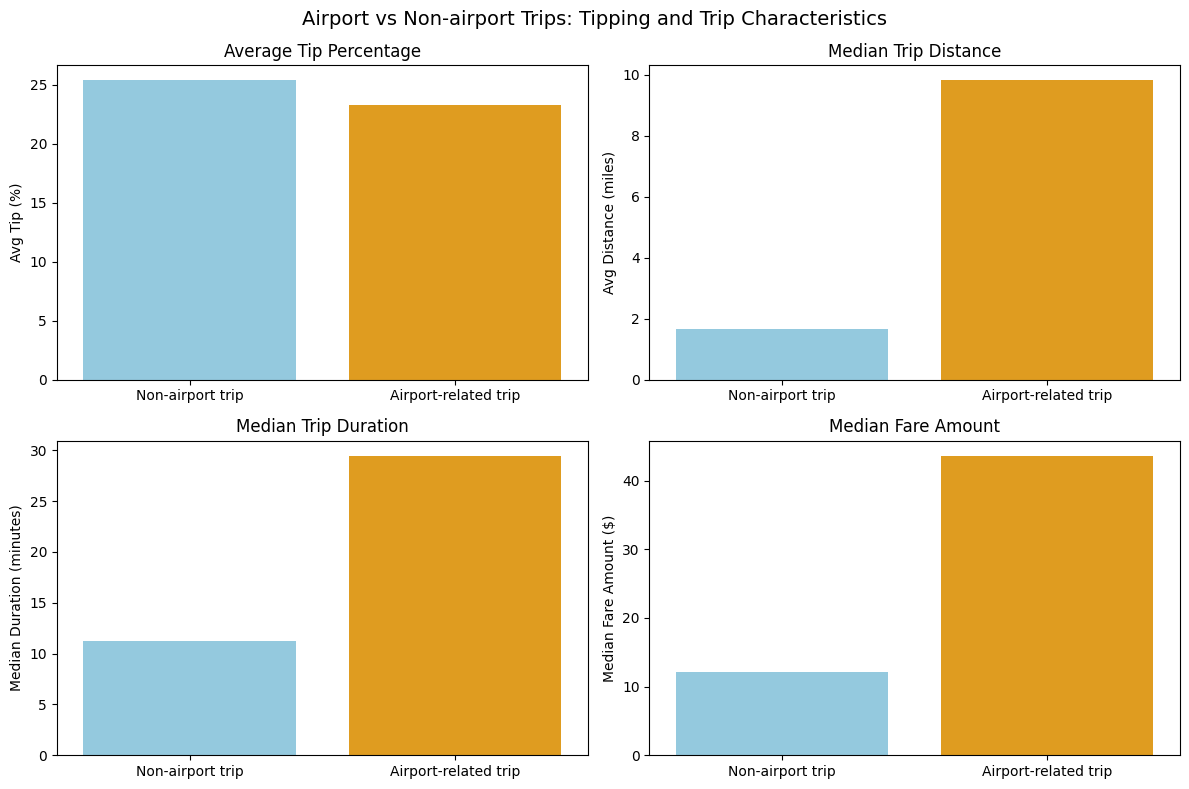

In [21]:
df["airport_trip_flag"] = (df["Airport_fee"].fillna(0) > 0).astype(int)

# Summary table
airport_summary = (
    df.groupby("airport_trip_flag")
    .agg(
        trip_count=("airport_trip_flag", "size"),
        avg_tip_percentage=("tip_percentage", "mean"),
        high_tip_rate=("high_tip", "mean"),
        median_distance=("trip_distance", "median"),
        median_duration=("trip_duration_minutes", "median"),
        median_fare=("fare_amount", "median")
    )
    .reset_index()
)

# Convert to percentage
airport_summary["avg_tip_percentage"] *= 100
airport_summary["high_tip_rate"] *= 100

# Rename categories
airport_summary["airport_trip_flag"] = airport_summary["airport_trip_flag"].map({
    0: "Non-airport trip",
    1: "Airport-related trip"
})

display(airport_summary)

# Define colors for 2 bars
bar_colors = {
    "Non-airport trip": "skyblue",
    "Airport-related trip": "orange"
}

# Plot separately
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(
    data=airport_summary,
    x="airport_trip_flag",
    y="avg_tip_percentage",
    hue="airport_trip_flag",
    palette=bar_colors,
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_title("Average Tip Percentage")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Avg Tip (%)")

sns.barplot(
    data=airport_summary,
    x="airport_trip_flag",
    y="median_distance",
    hue="airport_trip_flag",
    palette=bar_colors,
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_title("Median Trip Distance")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Avg Distance (miles)")

sns.barplot(
    data=airport_summary,
    x="airport_trip_flag",
    y="median_duration",
    hue="airport_trip_flag",
    palette=bar_colors,
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title("Median Trip Duration")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Median Duration (minutes)")

sns.barplot(
    data=airport_summary,
    x="airport_trip_flag",
    y="median_fare",
    hue="airport_trip_flag",
    palette=bar_colors,
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_title("Median Fare Amount")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Median Fare Amount ($)")

plt.suptitle("Airport vs Non-airport Trips: Tipping and Trip Characteristics", fontsize=14)
plt.tight_layout()
plt.show()

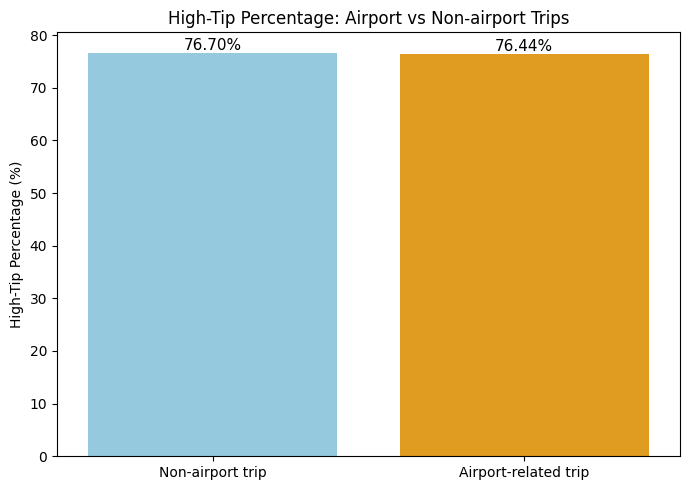

In [ ]:
df["airport_trip_flag"] = (df["Airport_fee"].fillna(0) > 0).astype(int)

high_tip_compare = (
    df.groupby("airport_trip_flag")["high_tip"]
    .mean()
    .reset_index()
)

high_tip_compare["high_tip"] = high_tip_compare["high_tip"] * 100

high_tip_compare["airport_trip_flag"] = high_tip_compare["airport_trip_flag"].map({
    0: "Non-airport trip",
    1: "Airport-related trip"
})

bar_colors = {
    "Non-airport trip": "skyblue",
    "Airport-related trip": "orange"
}

# Plot
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=high_tip_compare,
    x="airport_trip_flag",
    y="high_tip",
    hue="airport_trip_flag",
    palette=bar_colors,
    legend=False
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("High-Tip Percentage: Airport vs Non-airport Trips")
plt.xlabel("")
plt.ylabel("High-Tip Percentage (%)")
plt.tight_layout()
plt.show()

From the charts, there is obvious logic that the airport related trips are far more time consumed and had significantly longer distance which lead to a obviouly higher fare amount. However, the main problem to sau here is although the trips are longer, more time-consumed, the tip percentage and high tip percentage do not experience nay different from the not airport-related trips. We can partly explain the phenomenon as the price for these trips not only more costly, but they also comsumed airport fee that made these trips prominently expensive. And we are comparing the aspect of tip by percentage, so if we use the original currency, the tip amount of airport-related trip will remarkably outweight the other type. Overall, The airport-related aspect do affect the charateristics of the trips, but it do not affect the customer behaviour on tip fro drivers.